In [69]:
import os
import numpy as np
import pandas as pd
import pickle
import re
from aSPA import compute_aSPA_per_country
from tqdm import tqdm
from RF_direct import select_covariates

In [70]:
targets = ['Colombia', 'Greece', 'Turkey', 'Netherlands', 'Portugal', 'Nepal', 'Global Factor', 'Malawi', 'Hungary', 
           'Ecuador', 'Italy', 'Chile', 'Costa Rica', 'Uruguay', 'Korea, Rep.', 'India', 'Denmark', 'France', 'El Salvador', 
           'United Kingdom', 'Germany', 'Botswana', 'Nigeria', 'Paraguay', 'Mexico', 'Austria', 'Pakistan', 'Israel', 'Philippines', 
           'Jamaica', 'Niger', 'Cyprus', 'Slovenia', 'United States', 'Luxembourg', 'Japan', 'Sweden', 'Dominican Republic', 'Finland', 
           'South Africa', 'Morocco', 'Sri Lanka', 'Barbados', 'Spain', 'Norway', 'Fiji', 'Trinidad and Tobago', 'Honduras', 'Senegal', 
           'Ghana', 'Algeria', 'Mauritius', 'Sudan', 'Bahamas', 'Guatemala', 'Solomon Islands', 'Switzerland', "Cote d'Ivoire", 'Ireland', 
           'Malaysia', 'Jordan', 'Singapore', 'Canada', 'Malta', 'Belgium', 'Grenada', 'Egypt, Arab Rep.', 'Thailand', 'Iceland', 'Dominica', 
           'Panama', 'Ethiopia', 'Madagascar', 'Saudi Arabia', 'St. Lucia', 'Taiwan, China', 'Kenya', 'Burkina Faso', 'Samoa', 
           'St. Kitts and Nevis', 'Burundi', 'Myanmar', 'Suriname', 'Haiti', 'Indonesia', 'Gambia, The', 'Cameroon', 'Eswatini', 
           'Seychelles', 'Bolivia', 'Brazil', 'Peru']

In [71]:
continents = pd.read_csv('country-and-continent-codes-list-csv.csv')
continents.loc[(continents['Continent_Name'] == 'Oceania') | (continents['Continent_Name'] == 'Asia'), 'Continent_Name'] = 'Asia & Oceania'
continents[continents["Continent_Name"] == "North America"]
continents["Country_Name"] = continents["Country_Name"].apply(lambda x: x.split(",")[0].split(" (")[0])
continents = continents[['Country_Name', 'Continent_Name']].drop_duplicates()
country_to_continent = dict(zip(continents['Country_Name'], continents['Continent_Name']))
country_to_continent["United Kingdom"] = "Europe"
country_to_continent['St. Kitts and Nevis'] = "North America"
country_to_continent['St. Lucia'] = 'North America'
country_to_continent['Eswatini'] = 'Africa'
country_to_continent["United States"] = "North America"
country_to_continent["Taiwan, China"] = "Asia"
country_to_continent["Korea, Rep."] = "Asia"
country_to_continent["Gambia, The"] = "Africa"
country_to_continent["Egypt, Arab Rep."] = "Africa"

In [72]:
import os
import pickle
import pandas as pd
import numpy as np
from tqdm import tqdm
inflation_df = pd.read_csv("Inflation.csv", index_col=0, header = [0,1])
#CPI_df = pd.read_csv("CPI.csv", index_col=0, header = [0,1])


inflation_df.columns = inflation_df.columns.droplevel(1)
cols = inflation_df.columns.values  # Get column names as a NumPy array

# Rename only specific indexed columns
cols[-12] = "Global"

inflation_df.columns = cols


inflation_df.index = pd.to_datetime(inflation_df.index.astype(str), format='%Y%m')

inflation_df = inflation_df.asfreq("MS")

country_names = inflation_df.columns[:-12]


In [86]:
import os
import pickle
import pandas as pd
import numpy as np

def extract_linear_shap(model_type, horizon, forecasts_path, country_names):
    """
    Load SHAP explanations for DLinear/NLinear and return RF-style df_all.
    Handles missing 'columns' by reconstructing feature names.
    """
    fname = f"{model_type.lower()}_forecast_h{horizon}.pkl"
    fpath = os.path.join(forecasts_path, fname)

    with open(fpath, "rb") as f:
        data_dict = pickle.load(f)

    shap_obj = data_dict["shap_explanation"]

    # Explanation → ndarray
    if hasattr(shap_obj, "values"):
        shap_arr = shap_obj.values
    else:
        shap_arr = shap_obj

    # shape: (1, lags, n_features, steps*horizons)
    shap_arr = np.array(shap_arr).squeeze(0)
    lag_len, n_features, total = shap_arr.shape

    # reconstruct feature names
    if "columns" in data_dict:
        feature_names = list(data_dict["columns"])
    else:
        # 91 countries + Global + Month_2..Month_12
        feature_names = list(country_names) + ["Global"] + [f"Month_{m}" for m in range(2, 13)]
        assert len(feature_names) == n_features, f"Expected {n_features} features, built {len(feature_names)}"

    # infer number of steps
    assert total % horizon == 0, f"Cannot evenly split {total} into horizon={horizon}"
    n_steps = total // horizon

    # reshape → (lags, n_features, steps, horizons)
    shap_arr = shap_arr.reshape(lag_len, n_features, n_steps, horizon)

    records = []
    for lag in range(lag_len):
        for f_idx, feature in enumerate(feature_names):
            for step in range(n_steps):
                for h in range(horizon):
                    val = shap_arr[lag, f_idx, step, h]
                    records.append({
                        "timestamp": None,               # placeholder
                        "horizon": h + 1,                # 1-based horizon
                        "country": None,                 # predictors only
                        "feature": f"{feature}_lag{lag+1}",
                        "shap": val
                    })

    return pd.DataFrame(records)






df_all_dlinear = extract_linear_shap(
    model_type="DLinear",
    horizon=12,
    forecasts_path="dlinear_forecasts",
    country_names=country_names  # 91 countries
)

print(df_all_dlinear.head())
print(df_all_dlinear["feature"].nunique(), "unique features")
df_all_nlinear = extract_linear_shap(
    model_type="NLinear",
    horizon=12,
    forecasts_path="nlinear_forecasts",
    country_names=country_names  # 91 countries
)

print(df_all_nlinear.head())
print(df_all_nlinear["feature"].nunique(), "unique features")

  timestamp  horizon country       feature      shap
0      None        1    None  Austria_lag1  0.008097
1      None        2    None  Austria_lag1  0.017077
2      None        3    None  Austria_lag1 -0.006827
3      None        4    None  Austria_lag1 -0.004726
4      None        5    None  Austria_lag1  0.010772
2472 unique features
  timestamp  horizon country       feature      shap
0      None        1    None  Austria_lag1  0.003514
1      None        2    None  Austria_lag1  0.007541
2      None        3    None  Austria_lag1 -0.001722
3      None        4    None  Austria_lag1 -0.001484
4      None        5    None  Austria_lag1  0.002433
2472 unique features


In [84]:
df_all_dlinear

,timestamp,horizon,country,feature,shap
0,None,1,None,feat_0_lag1,0.008097
1,None,2,None,feat_0_lag1,0.017077
2,None,3,None,feat_0_lag1,-0.006827
3,None,4,None,feat_0_lag1,-0.004726
4,None,5,None,feat_0_lag1,0.010772
...,...,...,...,...,...
2699419,None,8,None,feat_102_lag24,0.000467
2699420,None,9,None,feat_102_lag24,0.000571
2699421,None,10,None,feat_102_lag24,0.001404
2699422,None,11,None,feat_102_lag24,-0.000637


In [73]:
import os
import pickle
import numpy as np
import pandas as pd
from tqdm import tqdm


def extract_rf_shap_all(results_path, inflation_df, select_covariates, country_name_map={"Cote d_Ivoire": "Cote d'Ivoire"}):
    """
    Extract SHAP values from RF results across all horizons × countries.
    Returns long-format DataFrame df_all with raw features.
    """
    shap_records = []
    all_files = [f for f in os.listdir(results_path) if f.endswith(".pkl")]

    for f in tqdm(all_files, desc="Processing RF files"):
        # filename: RF_forecast_h{horizon}_{country}.pkl
        parts = f.replace(".pkl", "").split("_")
        horizon = int(parts[2][1:])
        country = "_".join(parts[3:])
        if country_name_map:
            country_in_df = country_name_map.get(country, country)
        else:
            country_in_df = country

        with open(os.path.join(results_path, f), "rb") as fh:
            d = pickle.load(fh)

        shap_list = d["shap_explanation"]
        best_params = d["best_params"]
        forecasts = d["forecast"]

        for shap_arr, params, (ts, _) in zip(shap_list, best_params, forecasts):
            best_p = params["best_p"]

            # rebuild feature names at this step
            t_idx = inflation_df.index.get_loc(ts)
            full_data = inflation_df.iloc[:t_idx+1]
            X_forecast = select_covariates(full_data, country_in_df, p=best_p).iloc[[-1]]

            feature_names = X_forecast.columns
            if hasattr(shap_arr, "values"):
                shap_values = shap_arr.values.squeeze(0)
            else:
                shap_values = np.array(shap_arr).squeeze(0)

            for feat, val in zip(feature_names, shap_values):
                shap_records.append({
                    "timestamp": ts,
                    "horizon": horizon,
                    "country": country_in_df,   # target country
                    "feature": feat,            # raw feature name
                    "shap": val
                })

    df_all = pd.DataFrame(shap_records)
    return df_all


def assign_feature_group(df_all, country_to_continent):
    """
    Map raw feature names to higher-level groups:
    - monthly dummies
    - AR for target's own lags
    - Global Factor
    - Continent for other predictors
    """
    df_all = df_all.copy()

    def map_feature(row):
        feat = row["feature"]
        country = row["country"]  # target country

        # Monthly dummies → Monthly Dummies
        if feat.startswith("Month_"):
            return "Monthly Dummies"

        # Global factor
        if feat == "Global":
            return "Global Factor"

        # Target autoregressive lags
        if feat.startswith(f"{country}_lag_"):
            return "AR"

        # Otherwise: continent of predictor country
        predictor_country = feat.split("_")[0]
        return country_to_continent.get(predictor_country, "Other")

    df_all["feature_group"] = df_all.apply(map_feature, axis=1)
    return df_all


def aggregate_rf_shap(df_all, country_to_continent, target_continents):
    """
    Aggregate SHAP values by horizon × target_continent × predictor_group.
    """
    # assign feature groups
    df_all = assign_feature_group(df_all, country_to_continent)

    # map target country → continent
    df_all["target_continent"] = df_all["country"].map(lambda c: country_to_continent.get(c, "Other"))

    # absolute shap values
    df_all = df_all.assign(abs_shap=lambda d: d["shap"].abs())

    # aggregate
    agg = (
        df_all.groupby(["horizon", "target_continent", "feature_group"], as_index=False)["abs_shap"].sum()
    )

    # keep only selected target continents
    agg = agg[agg["target_continent"].isin(target_continents)]
    return df_all, agg


In [74]:
results_path = r"D:\results\RF_results\RF_forecasts"

# extract raw SHAP
df_all = extract_rf_shap_all(results_path, inflation_df, select_covariates)

# aggregate into groups
df_all, df_agg = aggregate_rf_shap(df_all, country_to_continent, 
                                   target_continents=["Africa", "Asia & Oceania", "Europe", "North America", "South America"])

print(df_all.head())  # raw, long-format
print(df_agg.head())  # aggregated, ready for plotting


Processing RF files: 100%|██████████| 1092/1092 [01:54<00:00,  9.50it/s]


   timestamp  horizon country       feature      shap feature_group  \
0 2010-10-01        8  Turkey  Turkey_lag_1 -0.068696            AR   
1 2010-10-01        8  Turkey  Turkey_lag_2 -0.022840            AR   
2 2010-10-01        8  Turkey  Turkey_lag_3 -0.097748            AR   
3 2010-10-01        8  Turkey  Turkey_lag_4 -1.266802            AR   
4 2010-10-01        8  Turkey       Austria  0.000022        Europe   

  target_continent  abs_shap  
0   Asia & Oceania  0.068696  
1   Asia & Oceania  0.022840  
2   Asia & Oceania  0.097748  
3   Asia & Oceania  1.266802  
4   Asia & Oceania  0.000022  
   horizon target_continent   feature_group   abs_shap
0        1           Africa              AR  36.515720
1        1           Africa          Africa  23.516328
2        1           Africa            Asia   2.032688
3        1           Africa  Asia & Oceania  23.328930
4        1           Africa          Europe  29.807424


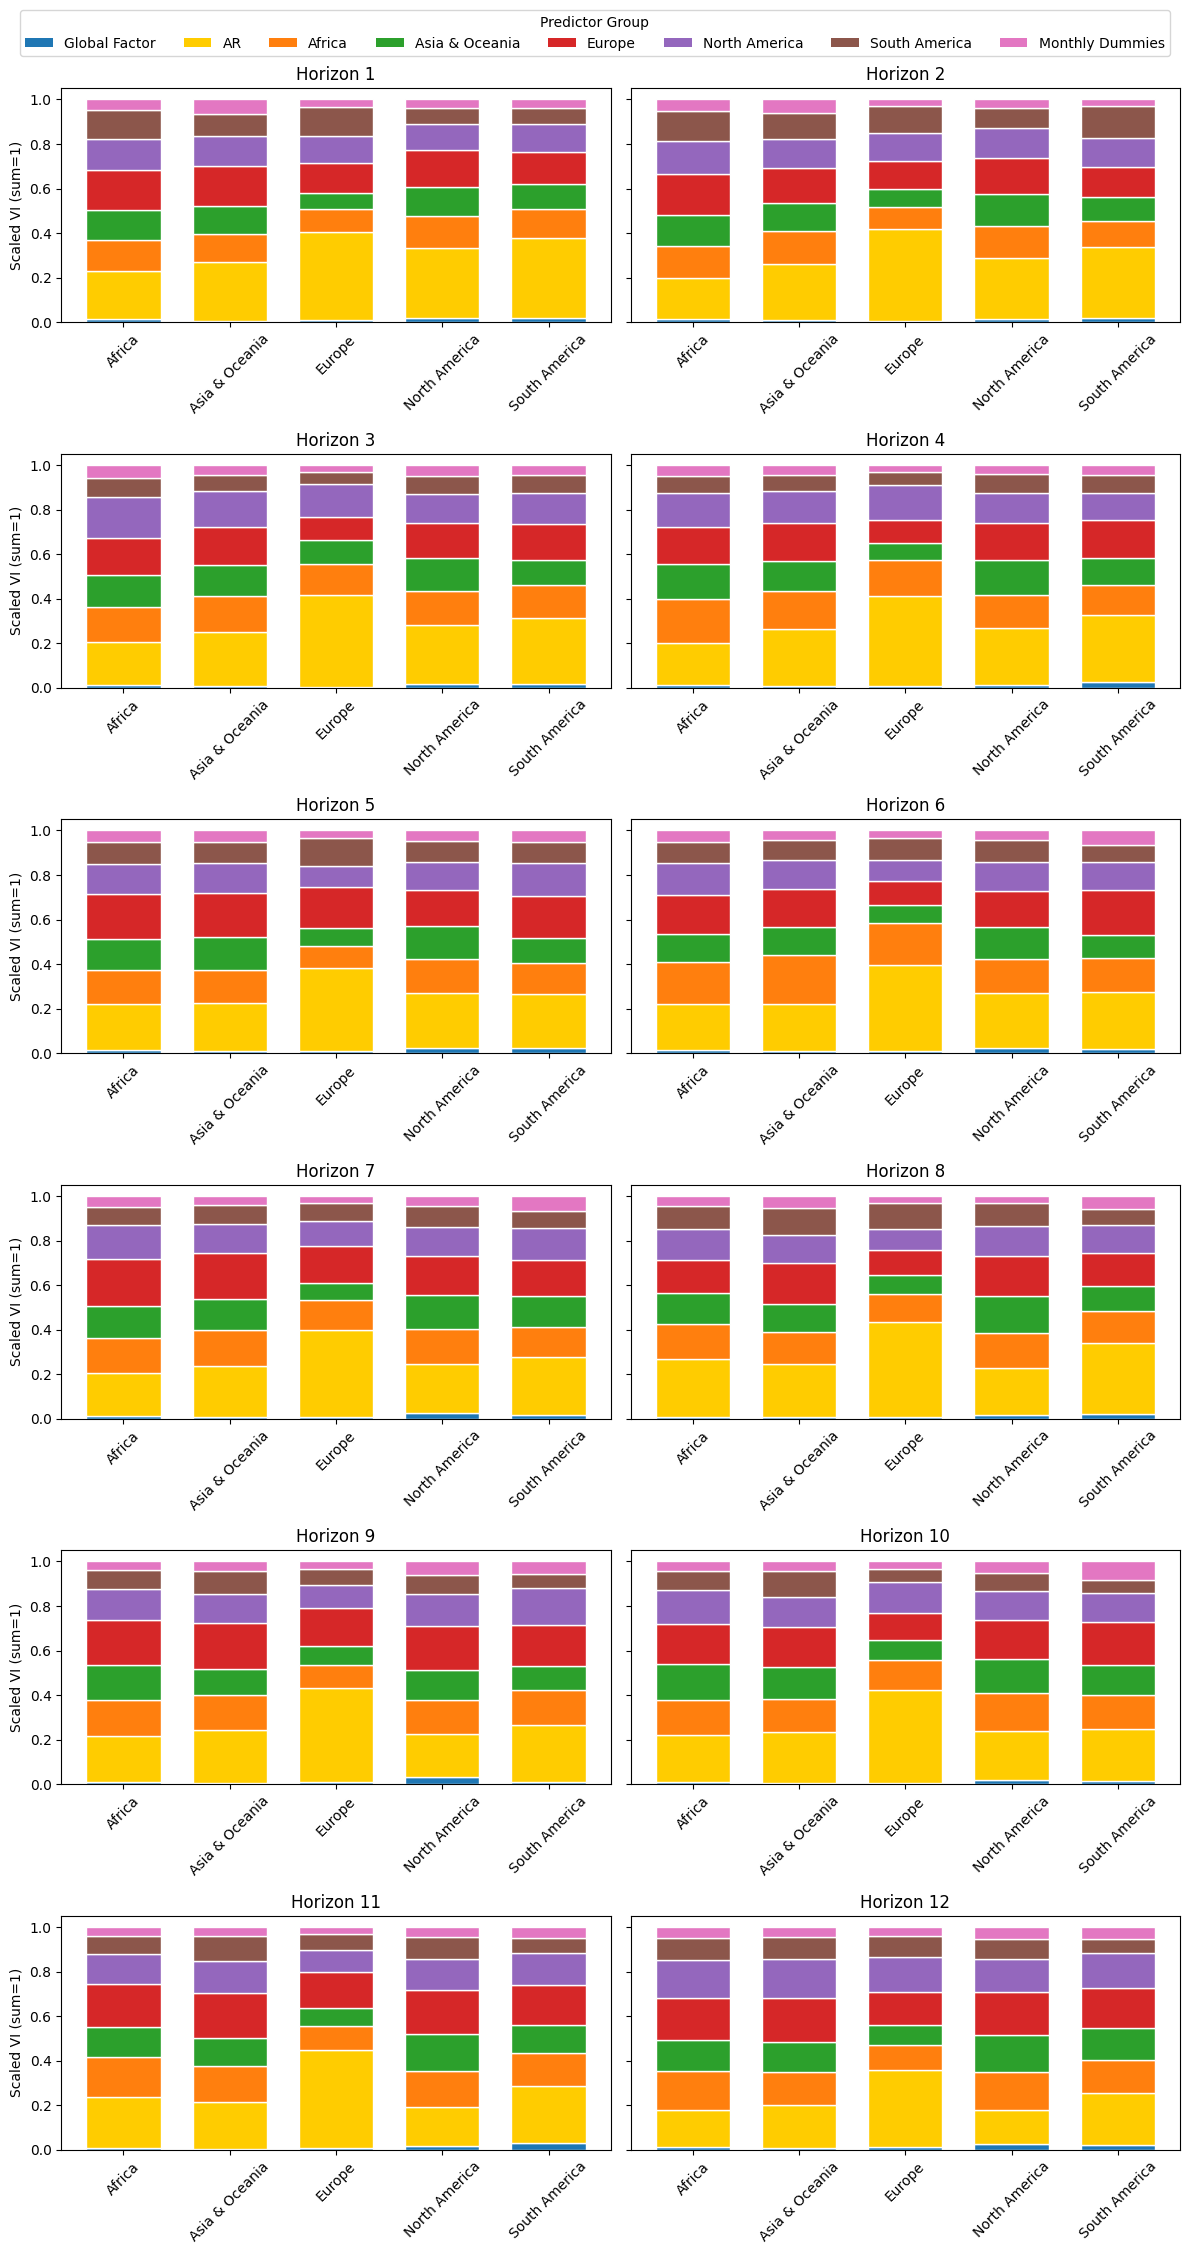

In [76]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

def plot_shap_vi_rf(
    model_name,
    df_agg,
    predictor_groups=["Global Factor", "AR", "Africa", "Asia & Oceania",
                      "Europe", "North America", "South America", "Monthly Dummies"],
    group_colors={
        "Global Factor": "#1f77b4",
        "AR": "#ffcc00",
        "Africa": "#ff7f0e",
        "Asia & Oceania": "#2ca02c",
        "Europe": "#d62728",
        "North America": "#9467bd",
        "South America": "#8c564b",
        "Monthly Dummies": "#e377c2"
    },
    target_continents=["Africa", "Asia & Oceania", "Europe",
                       "North America", "South America"],
    horizons=list(range(1, 13))  # 1–12 horizons
):
    """
    Plot stacked bar charts of SHAP VI for Random Forest across horizons and target continents.
    """

    num_horizons = len(horizons)
    cols = 2
    rows = (num_horizons + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharey=True)
    axes = axes.flatten()

    for idx, h in enumerate(horizons):
        ax = axes[idx]
        df_h = df_agg[df_agg["horizon"] == h]

        # pivot: rows = target_continent, cols = predictor_group
        plot_df = df_h.pivot(index="target_continent",
                             columns="feature_group",
                             values="abs_shap").fillna(0)

        # reorder rows & cols
        plot_df = plot_df.reindex(index=target_continents,
                                  columns=predictor_groups,
                                  fill_value=0)

        # normalize row-wise (sum=1 for each target continent)
        plot_df = plot_df.div(plot_df.sum(axis=1), axis=0)

        # stacked bars
        bottom = np.zeros(len(target_continents))
        x = np.arange(len(target_continents))
        for g in predictor_groups:
            heights = plot_df[g].values
            ax.bar(x, heights, bottom=bottom,
                   color=group_colors[g], edgecolor="white", width=0.7)
            bottom += heights

        ax.set_title(f"Horizon {h}")
        ax.set_xticks(x)
        ax.set_xticklabels(target_continents, rotation=45)
        if idx % cols == 0:
            ax.set_ylabel("Scaled VI (sum=1)")

    # remove unused axes
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    # legend
    legend_handles = [Patch(facecolor=group_colors[g], label=g) for g in predictor_groups]
    fig.legend(
        handles=legend_handles,
        title="Predictor Group",
        loc="upper center",
        ncol=len(predictor_groups),
        bbox_to_anchor=(0.5, 0.97)
    )

    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"plots/{model_name}_rf_plot.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_shap_vi_rf(
    model_name="RF_results",
    df_agg=df_agg
)

C:\Users\osahl\AppData\Local\Temp\ipykernel_25292\1639986137.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


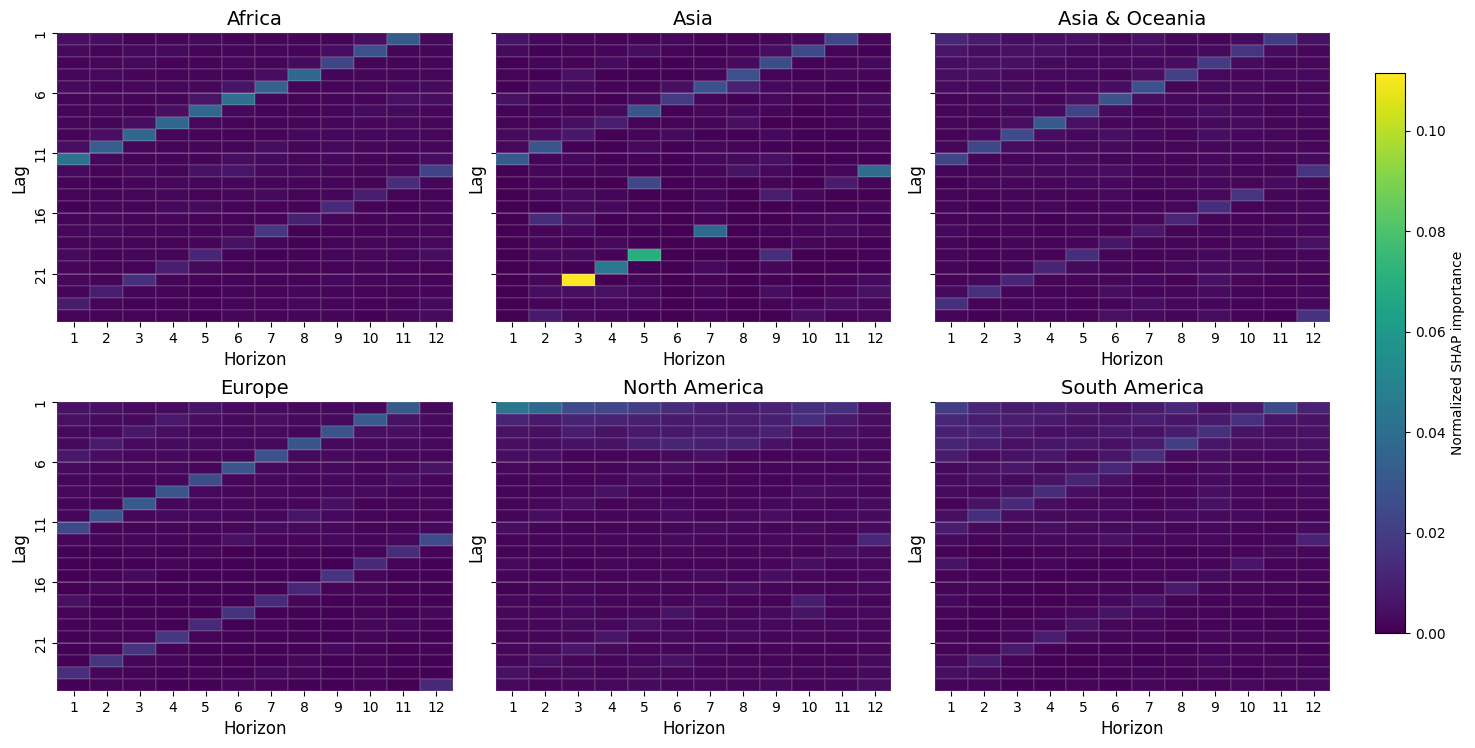

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

def create_rf_lag_heatmap(df_all, model_name="RF_results"):
    """
    Create lag-horizon heatmaps for RF SHAP values, grouped by target continent.
    """
    # keep only AR features
    df_ar = df_all[df_all["feature_group"] == "AR"].copy()

    # extract lag number from feature name "..._lag_k"
    df_ar["lag"] = df_ar["feature"].str.extract(r"lag_(\d+)").astype(int)

    # aggregate absolute SHAP by lag × horizon × target_continent
    df_ar = df_ar.assign(abs_shap=lambda d: d["shap"].abs())
    grouped = (
        df_ar.groupby(["target_continent", "horizon", "lag"], as_index=False)["abs_shap"].mean()
    )

    continents = grouped["target_continent"].unique()
    n = len(continents)

    # layout
    ncols = math.ceil(math.sqrt(n))
    nrows = math.ceil(n / ncols)

    # --- global vmin/vmax for color scale ---
    all_values = []
    for cont in continents:
        df_c = grouped[grouped["target_continent"] == cont]
        mat = df_c.pivot(index="lag", columns="horizon", values="abs_shap").fillna(0)
        mat = mat / mat.to_numpy().sum()  # normalize within continent
        all_values.append(mat.to_numpy())
    global_min = np.min([a.min() for a in all_values])
    global_max = np.max([a.max() for a in all_values])

    # --- plotting ---
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(5*ncols, 4*nrows),
        squeeze=False,
        sharey=True
    )

    for ax, cont in zip(axes.flat, continents):
        df_c = grouped[grouped["target_continent"] == cont]
        mat = df_c.pivot(index="lag", columns="horizon", values="abs_shap").fillna(0)
        mat = mat / mat.to_numpy().sum()

        sns.heatmap(
            mat,
            cmap="viridis",
            vmin=global_min, vmax=global_max,
            cbar=False,
            ax=ax,
            linewidths=0.2,
            linecolor=(0.9, 0.9, 0.9, 0.1)
        )

        # relabel horizons
        horizons = mat.columns
        ax.set_xticks(np.arange(len(horizons)) + 0.5)
        ax.set_xticklabels(horizons, fontsize=10)

        # lag ticks every 5
        ax.set_yticks(range(0, mat.shape[0], 5))
        ax.set_yticklabels(range(1, mat.shape[0]+1, 5), fontsize=10)

        # faint horizontal guides
        for y in np.arange(5, mat.shape[0], 5):
            ax.axhline(y, color="white", lw=0.5, alpha=0.3)

        ax.set_title(cont, fontsize=14)
        ax.set_xlabel("Horizon", fontsize=12)
        ax.set_ylabel("Lag", fontsize=12)

    # remove unused subplots
    for j in range(len(continents), nrows*ncols):
        fig.delaxes(axes.flat[j])

    # shared colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=global_min, vmax=global_max))
    fig.colorbar(norm, cax=cbar_ax, label="Normalized SHAP importance")

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.subplots_adjust(top=0.9)
    plt.savefig(f"plots/{model_name}_lag_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()

create_rf_lag_heatmap(df_all, model_name="RF_results")

In [60]:
import os
import pickle
import numpy as np
import pandas as pd

def compute_shap_vi(
    results_path, 
    shap_filename="shap_explanation_full.pkl", 
    pred_filename="prediction.pkl",
    country_to_continent=country_to_continent,
    targets_subset=None,
    horizon_subset=None
):
    """
    Compute SHAP variable importance (VI) from saved results, with optional subsetting.

    Parameters
    ----------
    results_path : str
        Path containing subfolders with SHAP and prediction files.
    shap_filename : str
        Filename of the SHAP pickle file.
    pred_filename : str
        Filename of the prediction pickle file.
    country_to_continent : dict, optional
        Mapping from feature/target names to continents.
    features_subset : list of str, optional
        Only compute VI for these features.
    targets_subset : list of str, optional
        Only compute VI for these targets.
    horizon_subset : list of int, optional
        Only compute VI for these horizons (0-based indices).

    Returns
    -------
    df_overall : pd.DataFrame
        Overall VI per feature.
    df_lag_melt : pd.DataFrame
        Lag-specific VI in long format for plotting.
    """
    folders = sorted(os.listdir(results_path), key=lambda x: int(x.split("_")[0]))

    vi_overall_list = []
    vi_lag_list = []

    for folder in folders:
        folder_path = os.path.join(results_path, folder)
        shap_path = os.path.join(folder_path, shap_filename)
        pred_path = os.path.join(folder_path, pred_filename)

        if not os.path.exists(shap_path) or not os.path.exists(pred_path):
            print(f"Skipping {folder} (missing file)")
            continue

        with open(shap_path, "rb") as fh:
            shap_obj = pickle.load(fh)
        with open(pred_path, "rb") as fh:
            pred_dict = pickle.load(fh)

        shap_values = shap_obj.values.squeeze(0)  # (n_lags, n_features, horizon*targets)
        n_lags, n_features, _ = shap_values.shape
        horizon, n_targets = pred_dict["predictions"].squeeze(0).shape
        columns = pred_dict["columns"]
        shap_values = shap_values.reshape(n_lags, n_features, horizon, n_targets)

        # Subset features
        columns_subset = columns.copy()

        # Subset targets
        if targets_subset is not None:
            target_idx = [columns.index(t) for t in targets_subset]
            shap_values = shap_values[:, :, :, target_idx]

        # Subset horizon
        if horizon_subset is not None:
            shap_values = shap_values[:, :, horizon_subset, :]

        # Map features to continents
        if country_to_continent is None:
            country_to_continent = {}
        feature_to_continent = [country_to_continent.get(f, "Global Factor") for f in columns_subset]
        feature_to_continent.append("TE")

        # --- Lag-specific VI ---
        vi_m_lag = np.abs(shap_values).mean(axis=(2, 3))
        if np.isnan(vi_m_lag).any():
            pass
        else:
            vi_lag_list.append(vi_m_lag)

        # --- Overall VI ---
        vi_m_overall = vi_m_lag.mean(axis=0)
        vi_overall_list.append(vi_m_overall)

    # Align lags
    feature_names = columns_subset + ["TE"]
    max_lags = max(v.shape[0] for v in vi_lag_list)
    aligned_lag = np.zeros(
        (len(vi_lag_list), max_lags, len(feature_names)),
        dtype=float
    )
    for i, v in enumerate(vi_lag_list):
        aligned_lag[i, :v.shape[0], :] = v

    VI_lag = aligned_lag.mean(axis=0)
    VI_overall = np.nanmean(np.stack(vi_overall_list, axis=0), axis=0)

    df_overall = pd.DataFrame({
        "feature": feature_names,
        "VI_overall": VI_overall
    }).sort_values("VI_overall", ascending=False)

    df_lag = pd.DataFrame(VI_lag, columns=feature_names)
    df_lag["lag"] = np.arange(1, VI_lag.shape[0]+1)
    df_lag_melt = df_lag.melt(id_vars="lag", var_name="feature", value_name="VI_lag")

    # Continent-level aggregation
    df_overall["continent"] = feature_to_continent

    df_lag_melt["continent"] = df_lag_melt["feature"].map(
        lambda x: feature_to_continent[columns_subset.index(x)] if x != "TE" else "TE"
    )

    return df_overall, df_lag_melt


In [84]:
model_name = "Informer_h12_results"
# Define horizons
horizons = list(range(12))  # example: 12-step forecast

def get_shaps(model_name=model_name):
    results_path = rf"D:\results\{model_name}\results"
    # Map each target to its continent
    continent_targets = {}
    for t in targets:
        continent = country_to_continent.get(t, "Global Factor")
        if continent not in continent_targets:
            continent_targets[continent] = []
        continent_targets[continent].append(t)

# Define horizons
    horizons = list(range(12))  # example: 12-step forecast

# Loop over continents and horizons
    results_by_continent_horizon = {}

    for continent, continent_target_list in continent_targets.items():
        results_by_continent_horizon[continent] = {}
    
        for h in tqdm(horizons):
            df_overall, df_lag_melt = compute_shap_vi(
            results_path=results_path,
            country_to_continent=country_to_continent,
            targets_subset=continent_target_list,  # only limit targets
            horizon_subset=[h]                      # subset to this horizon
        )
            df_overall["horizon"] = h
            df_lag_melt["horizon"] = h
        # Save results
            results_by_continent_horizon[continent][h] = {
            "df_overall": df_overall,
            "df_lag_melt": df_lag_melt
        }
            
    return results_by_continent_horizon, continent_targets


In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

def plot_shap_vi_for_model(
    model_name="Informer_h12_results",
    results_by_continent_horizon=None,
    continent_targets=None,
    horizons=list(range(0, 12)),  # Default: 12-step forecast
    predictor_groups=["Global Factor", "Africa", "Asia & Oceania", "Europe", "North America", "South America", "TE"],
    group_colors={
        "Global Factor": "#1f77b4",
        "Africa": "#ff7f0e",
        "Asia & Oceania": "#2ca02c",
        "Europe": "#d62728",
        "North America": "#9467bd",
        "South America": "#8c564b",
        "TE": "#e377c2"
    },
    target_continents=["Africa", "Asia & Oceania", "Europe", "North America", "South America"]
):
    """
    Generate and save SHAP VI plots for a given model.

    Parameters
    ----------
    model_name : str, optional
        Name of the model (used for saving the plot). Default is "Informer_h12_results".
    results_by_continent_horizon : dict, optional
        Results dictionary containing SHAP VI data for each continent and horizon. Default is None.
    continent_targets : dict, optional
        Mapping of continents to their respective targets. Default is None.
    horizons : list, optional
        List of horizons to plot. Default is [1, 2, ..., 12].
    predictor_groups : list, optional
        List of predictor groups. Default includes "Global Factor", "Africa", "Asia & Oceania", etc.
    group_colors : dict, optional
        Dictionary mapping predictor groups to their colors. Default includes predefined colors.
    target_continents : list, optional
        List of target continents. Default includes "Africa", "Asia & Oceania", etc.
    """
    if results_by_continent_horizon is None or continent_targets is None:
        raise ValueError("Both 'results_by_continent_horizon' and 'continent_targets' must be provided.")

    # Set up subplots
    num_horizons = len(horizons)
    cols = 2
    rows = (num_horizons + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharey=True)
    axes = axes.flatten()

    for idx, h in enumerate(horizons):
        ax = axes[idx]

        # Prepare data
        data = {pred: [] for pred in predictor_groups}

        for target_continent in target_continents:
            targets_in_continent = continent_targets.get(target_continent, [])
            if not targets_in_continent:
                for pred in predictor_groups:
                    data[pred].append(0)
                continue

            # Collect df_overall for all targets in this continent
            dfs = []
            for cont in continent_targets.keys():
                df = results_by_continent_horizon[cont][h]["df_overall"]
                df_target = df[df['feature'].isin(targets_in_continent)]
                dfs.append(df_target)
            df_target_h = pd.concat(dfs, ignore_index=True)

            vi_by_pred = df_target_h.groupby('continent')['VI_overall'].sum()
            for pred in predictor_groups:
                data[pred].append(vi_by_pred.get(pred, 0))

        # Convert to DataFrame and normalize
        plot_df = pd.DataFrame(data, index=target_continents)
        plot_df = plot_df.div(plot_df.sum(axis=1), axis=0)

        # Plot stacked bars
        plot_values = plot_df.values
        bottom = np.zeros(plot_values.shape[0])
        x = np.arange(len(target_continents))

        for i, pred in enumerate(predictor_groups):
            heights = plot_values[:, i]
            ax.bar(x, heights, bottom=bottom, color=group_colors[pred], edgecolor='white', width=0.6)
            bottom += heights

        # Only show X-axis labels on the bottom row of subplots
        if idx >= (rows - 1) * cols:
            ax.set_xticks(x)
            ax.set_xticklabels(target_continents, rotation=45)
        else:
            ax.set_xticks(x)
            ax.set_xticklabels([])  # hide labels for upper rows

        ax.set_title(f"Horizon {h+1}")
        if idx % cols == 0:
            ax.set_ylabel("Scaled VI (sum=1)")

    # Remove empty subplots if any
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    # Single legend at the top
    legend_handles = [Patch(facecolor=group_colors[p], label=p) for p in predictor_groups]
    fig.legend(
        handles=legend_handles,
        title="Predictor Group",
        loc='upper center',
        ncol=len(predictor_groups),
        bbox_to_anchor=(0.5, 0.97)
    )

    # Adjust layout to reduce top and bottom space
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Save the plot
    plt.savefig(f"plots/{model_name}_h12_plot.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)  # Close the figure to free memory

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

def create_lag_heatmap(results_by_continent_horizon, model_name="Informer_h12_results"):
    # drop Global Factor
    continents = [c for c in results_by_continent_horizon.keys() if c != "Global Factor"]
    n = len(continents)

    # figure out subplot layout dynamically
    ncols = math.ceil(math.sqrt(n))
    nrows = math.ceil(n / ncols)

    # --- compute global vmin/vmax for consistent colormap ---
    all_values = []
    for continent, horizon_dict in results_by_continent_horizon.items():
        if continent == "Global Factor":
            continue
        df_all = pd.concat(
            [horizon_dict[h]["df_lag_melt"] for h in horizon_dict],
            ignore_index=True
        )
        heatmap_data = (
            df_all.groupby(["lag", "horizon"])["VI_lag"]
            .mean()
            .reset_index()
            .pivot(index="lag", columns="horizon", values="VI_lag")
        )
        heatmap_data = heatmap_data / heatmap_data.to_numpy().sum()
        all_values.append(heatmap_data.to_numpy())

    global_min = np.min([a.min() for a in all_values])
    global_max = np.max([a.max() for a in all_values])

    # --- plotting ---
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(5*ncols, 4*nrows),
        squeeze=False,
        sharey=True  # align lag axes
    )

    for ax, continent in zip(axes.flat, continents):
        horizon_dict = results_by_continent_horizon[continent]
        df_all = pd.concat(
            [horizon_dict[h]["df_lag_melt"] for h in horizon_dict],
            ignore_index=True
        )
        heatmap_data = (
            df_all.groupby(["lag", "horizon"])["VI_lag"]
            .mean()
            .reset_index()
            .pivot(index="lag", columns="horizon", values="VI_lag")
        )
        heatmap_data = heatmap_data / heatmap_data.to_numpy().sum()

        # plot heatmap without internal gridlines
        sns.heatmap(
            heatmap_data,
            cmap="viridis",
            vmin=global_min, vmax=global_max,
            cbar=False,
            ax=ax,
            linewidths=0.2,
            linecolor=(0.9, 0.9, 0.9, 0.1)  # light gray, 10% opacity
        )


        # relabel horizons so they start at 1
        horizons = heatmap_data.columns
        ax.set_xticks(np.arange(len(horizons)) + 0.5)
        ax.set_xticklabels(horizons + 1, fontsize=10)

        # show lag ticks every 5
        ax.set_yticks(range(0, heatmap_data.shape[0], 5))
        ax.set_yticklabels(range(1, heatmap_data.shape[0]+1, 5), fontsize=10)

        # faint horizontal guides every 5 lags
        for y in np.arange(5, heatmap_data.shape[0], 5):
            ax.axhline(y, color="white", lw=0.5, alpha=0.3)

        # labels and title
        ax.set_title(continent, fontsize=14)
        ax.set_xlabel("Horizon", fontsize=12)
        ax.set_ylabel("Lag", fontsize=12)

    # remove unused axes if grid has extra slots
    for j in range(len(continents), nrows*ncols):
        fig.delaxes(axes.flat[j])

    # add one shared colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.cm.ScalarMappable(
        cmap="viridis", norm=plt.Normalize(vmin=global_min, vmax=global_max)
    )
    fig.colorbar(norm, cax=cbar_ax, label="Normalized SHAP importance")
    plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave room for colorbar
    plt.subplots_adjust(top=0.9)
    plt.savefig(f"plots/{model_name}_lag_heatmap.png", dpi=300, bbox_inches='tight')
    plt.show()


100%|██████████| 12/12 [00:33<00:00,  2.76s/it]


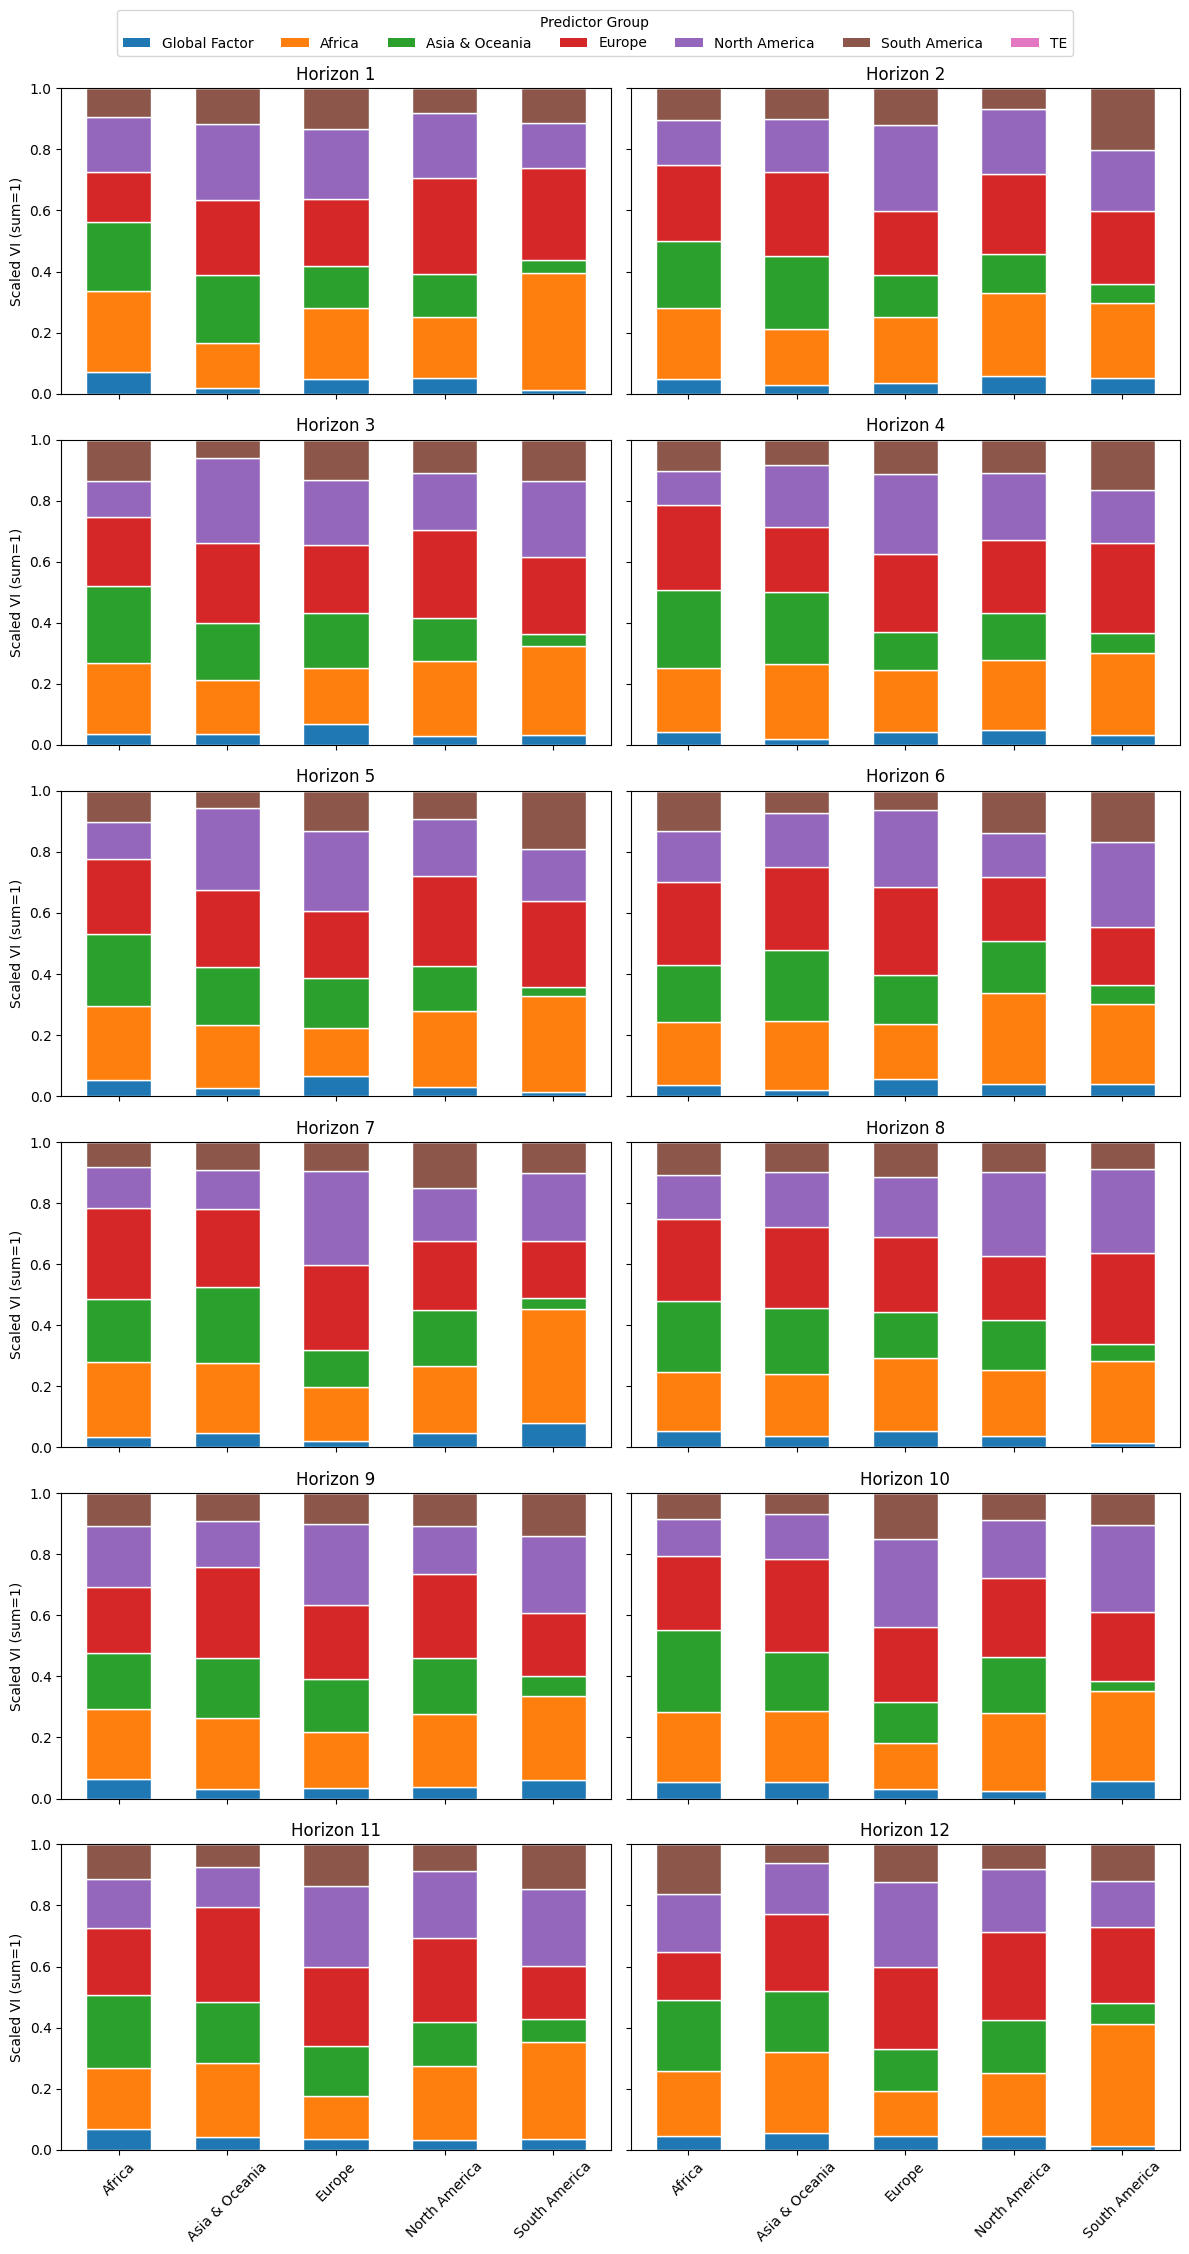

C:\Users\osahl\AppData\Local\Temp\ipykernel_21416\721225120.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave room for colorbar


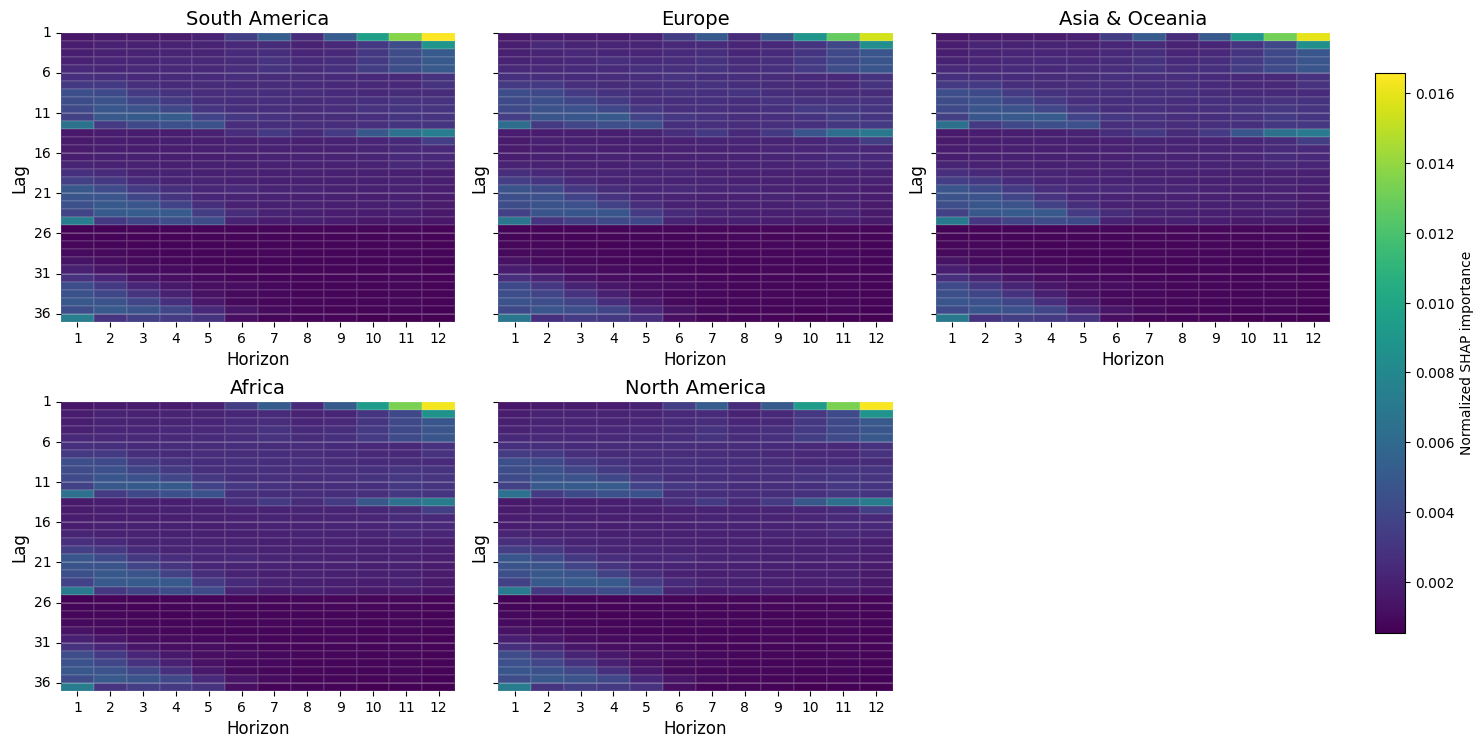

100%|██████████| 12/12 [00:29<00:00,  2.48s/it]


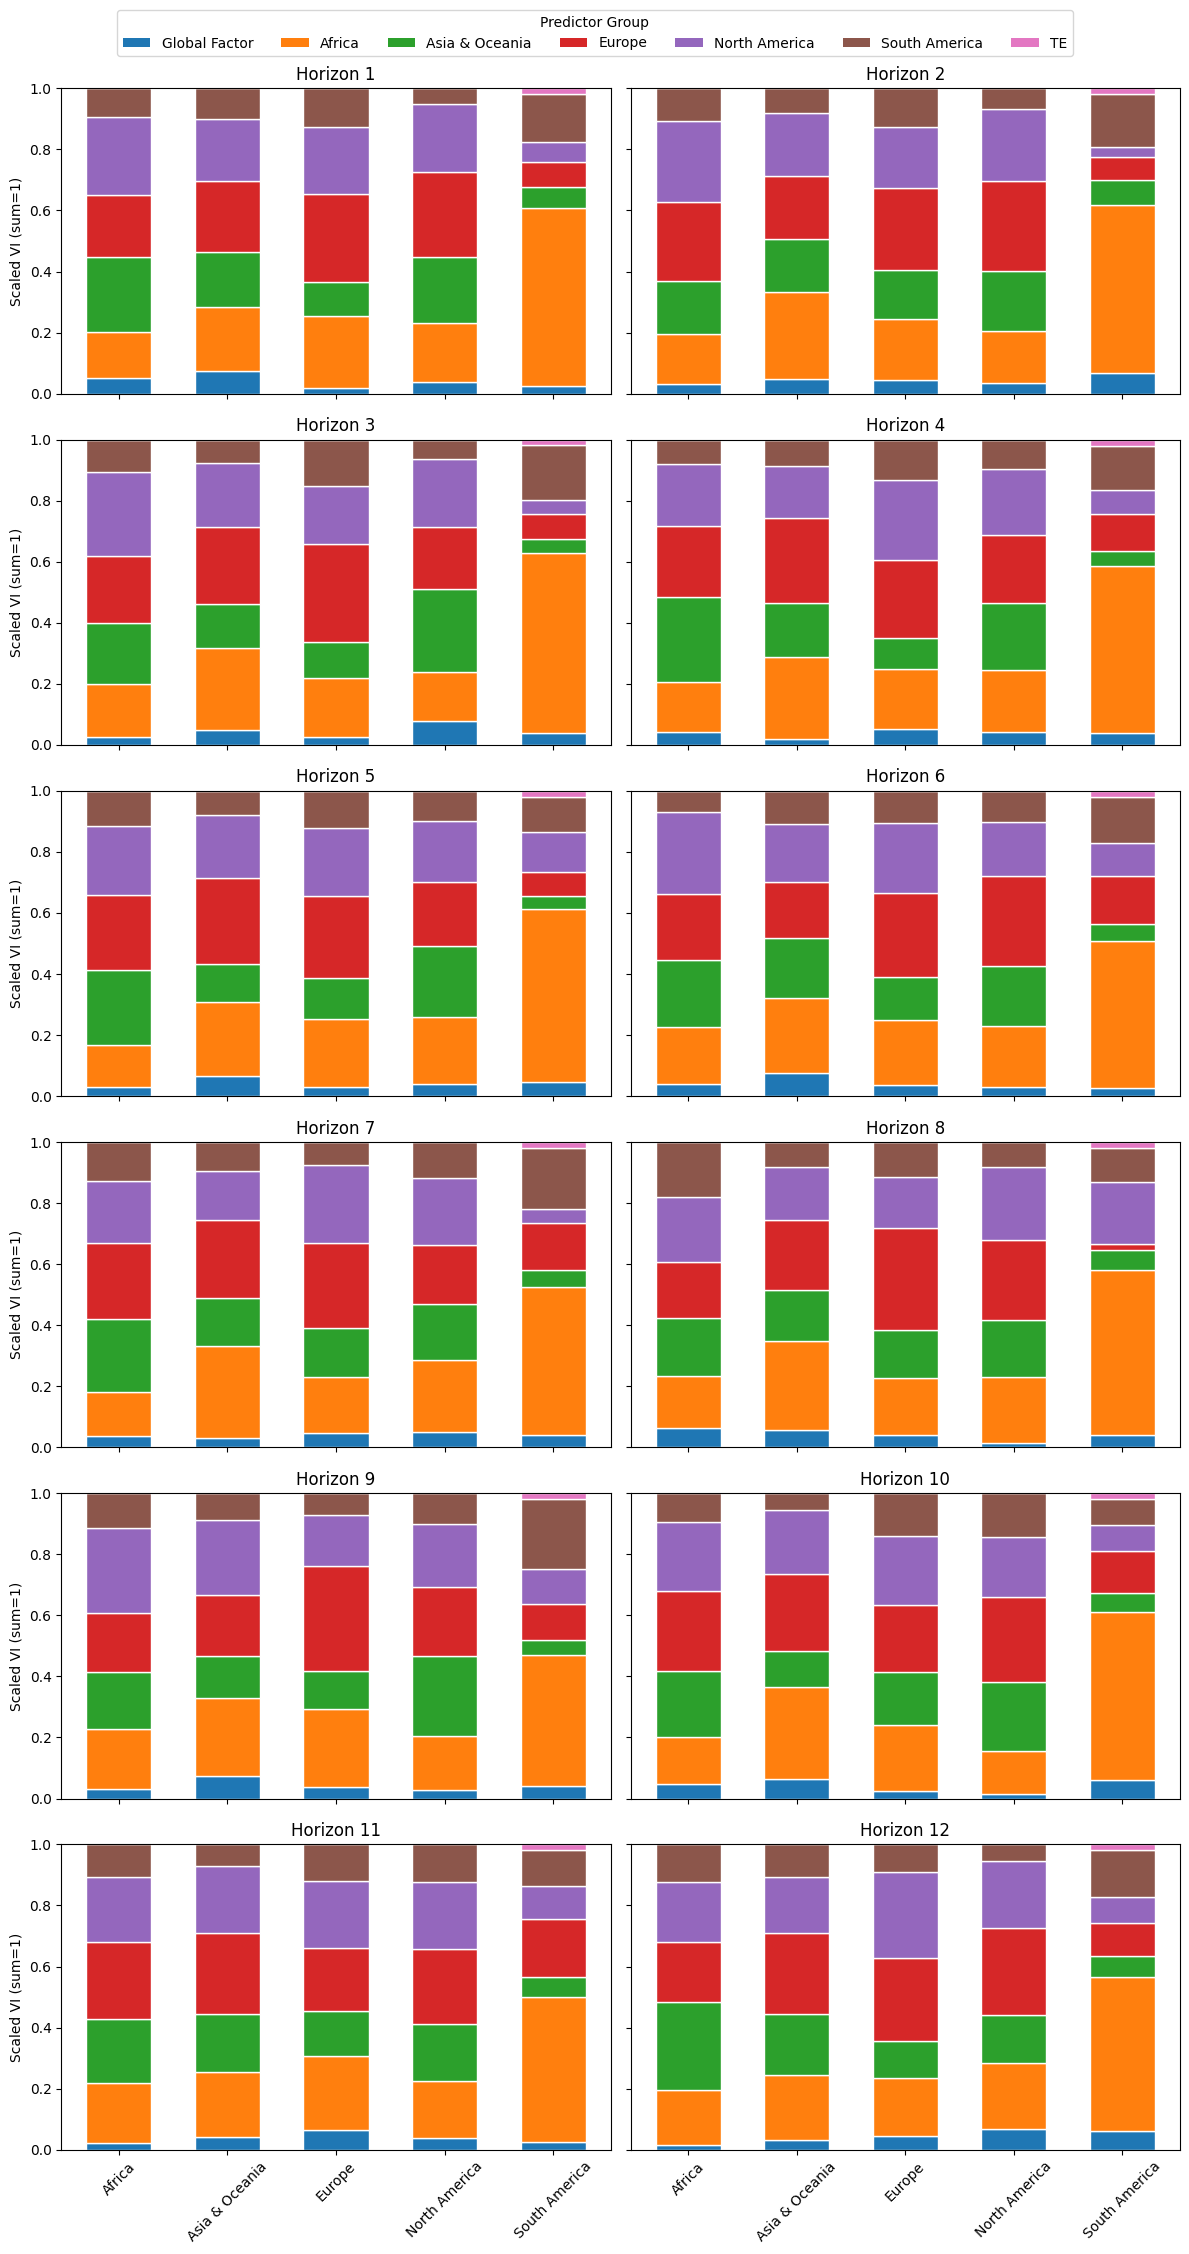

C:\Users\osahl\AppData\Local\Temp\ipykernel_21416\721225120.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave room for colorbar


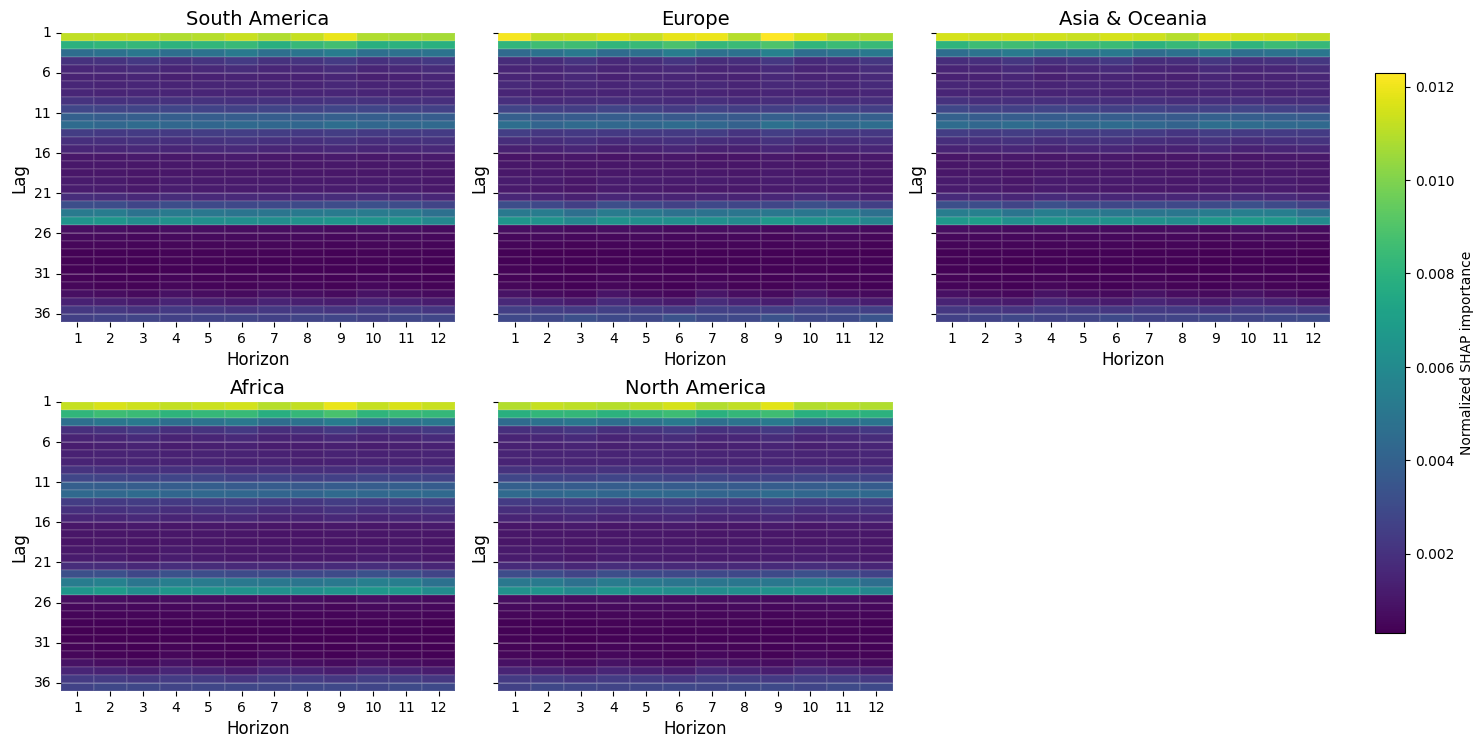

100%|██████████| 12/12 [00:33<00:00,  2.79s/it]


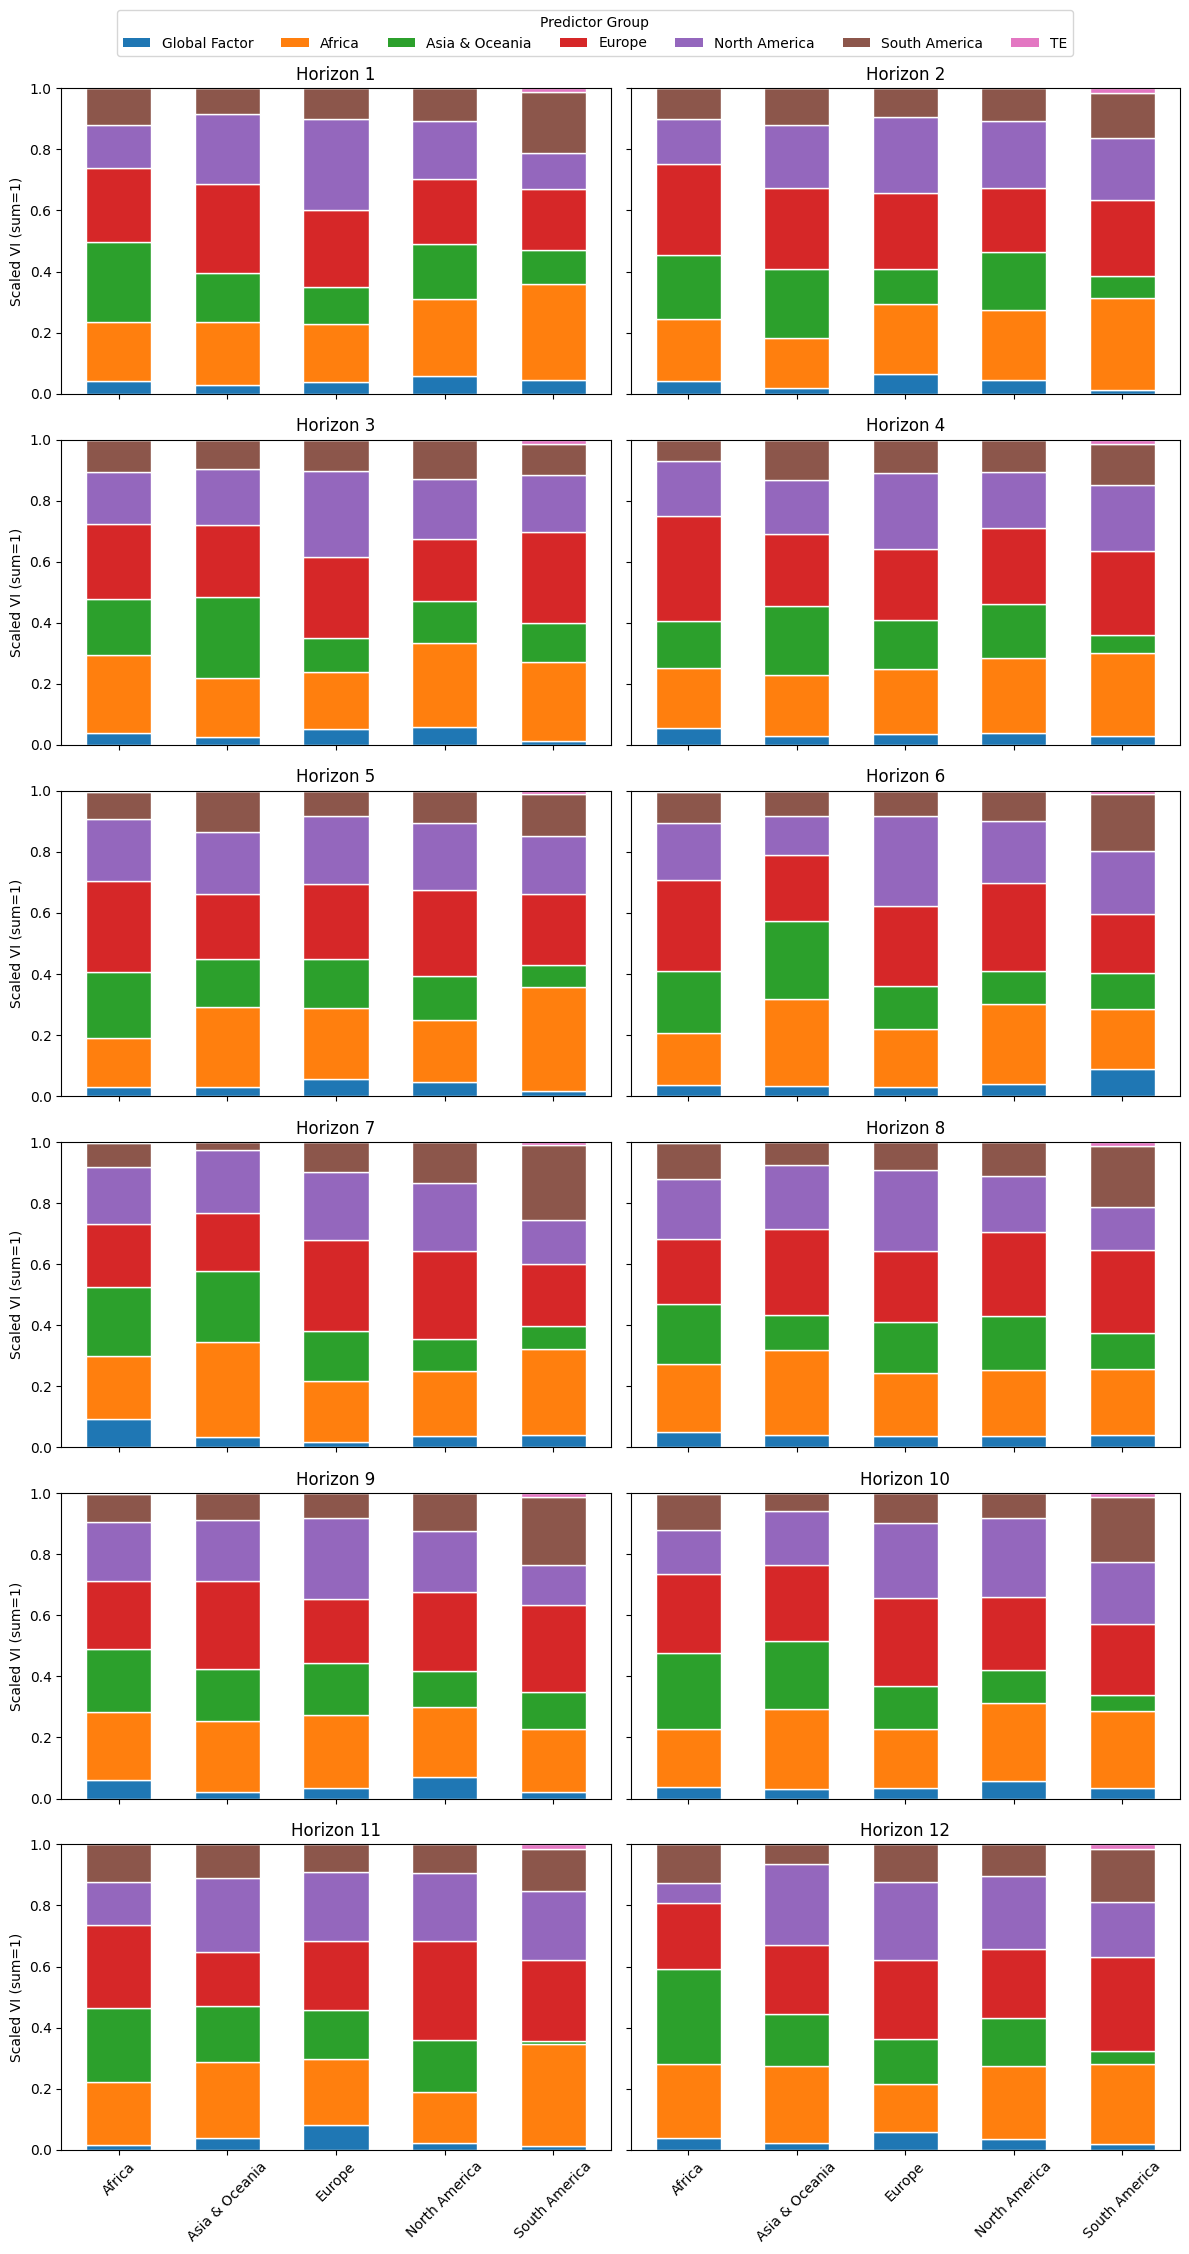

C:\Users\osahl\AppData\Local\Temp\ipykernel_21416\721225120.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave room for colorbar


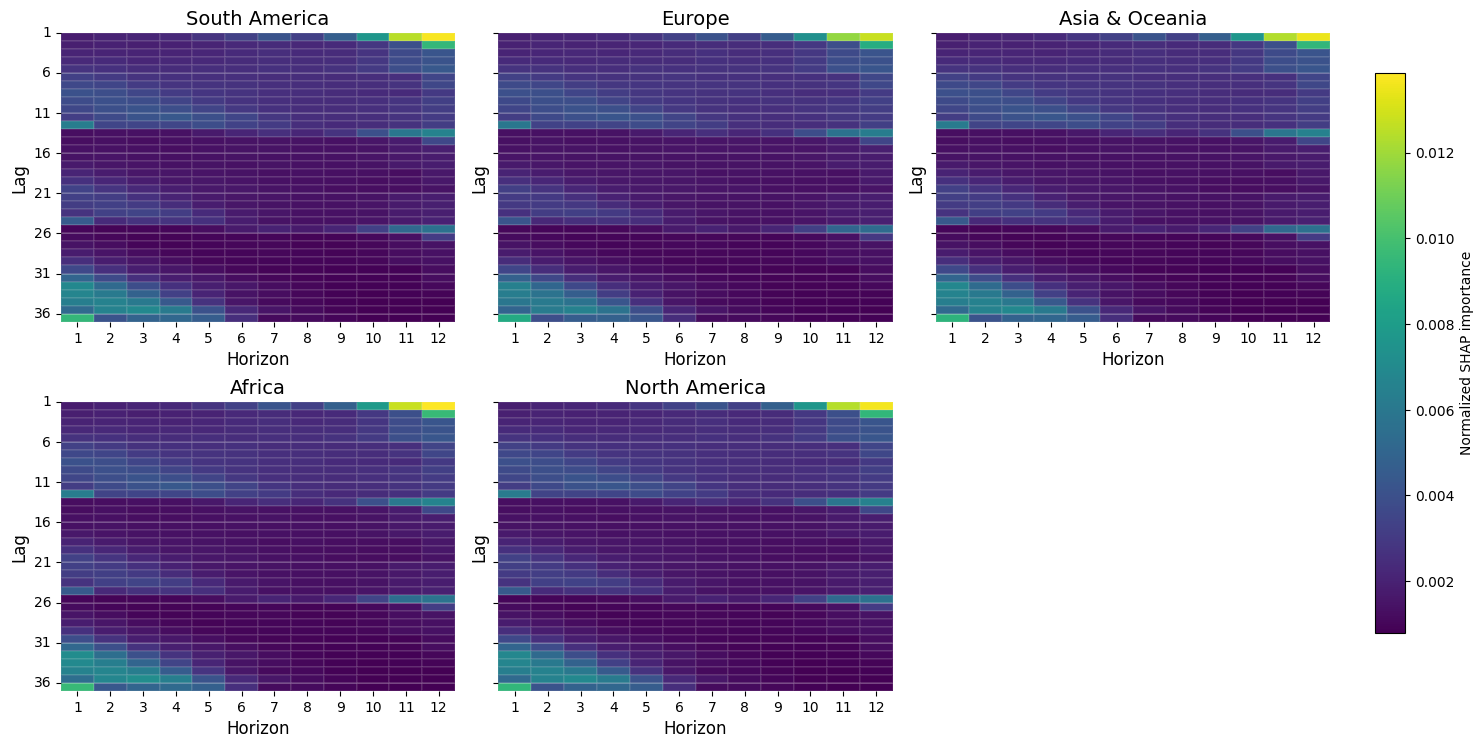

In [87]:
for model_name in ["FEDFormer_h12_results", "Informer_h12_results", "Autoformer_h12_results"]:
    results_by_continent_horizon, continent_targets = get_shaps(model_name=model_name)
    plot_shap_vi_for_model(
        model_name=model_name,
        results_by_continent_horizon=results_by_continent_horizon,
        continent_targets=continent_targets
    )
    create_lag_heatmap(results_by_continent_horizon, model_name=model_name)